# OTC Option portfolio: Hedging and risk analysis


* Options on: **WALT DISNEY CO.**
* Chosen business day: **Nov 12, 2025**
* Historic VaR time horizon: **2018-01-02 – 2025-11-12**

Anomaly in trading volume in the chosen day and a volatility premium on traded options create a market-making opportunity. Hedging for a portfolio of sold OTC options to clients as well as a comprehensive study of the risks to which it is exposed is provided using a historical data approach. The time-horizon for the statically hedged portfolio is 5-days.

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from dateutil.relativedelta import relativedelta as tdelta
from scipy.stats import norm
from scipy.interpolate import interp1d
from collections import defaultdict
from scipy.interpolate import CubicSpline

In [2]:
mpl.rcParams.update({
    "axes.grid": True,
    "axes.facecolor": "#F0F0F0",
    "axes.linewidth": 0,
    "figure.figsize": (10, 4),
    "figure.dpi": 300,
    "grid.color": "white",
    "lines.linewidth": 2.0,
})

# 1. Data Gathering & Selection

All market data gathered from Bloomberg.

## Stock Data

In [3]:
spot_data = pd.read_excel("data/Equity.xlsx", header=[0, 1], index_col=0).droplevel(1, axis=1)

## Listed Options

In [4]:
options_df = pd.read_excel(f"data/DIS.xlsx", header=[0, 1], index_col=0).dropna(how="all")
options_df = options_df.unstack().to_frame("Value").rename_axis(["Description", "Ticker", "Date"]).reset_index()
options_df["OptionType"] = options_df.Description.apply(lambda x: "call" if x.split()[-2][0] == "C" else "put")
options_df["Strike"] = options_df.Description.apply(lambda x: int(x.split()[-2][1:]))
options_df["Maturity"] = options_df.Description.apply(lambda x: x.split()[2])
options_df.Maturity = pd.to_datetime(options_df.Maturity, format="%m/%d/%y")

## Chosen Business Day

In [5]:
# Chosen value date
value_date = pd.to_datetime("20251112")

## Risk Free Rate Curve

We construct the Risk Free Rate curve considering non-business days (weekends) with modified following convention for tenor calculation, and the rates are continuous compounding, consistent with the Black-Scholes model we will use for portfolio valuation.

In [6]:
def is_business_day(date):
    date = pd.to_datetime(date)
    dates = pd.bdate_range(date - pd.Timedelta(days=5), date + pd.Timedelta(days=5), freq="C").to_numpy()
    return date in dates

def following(date):
    date = pd.to_datetime(date)
    dates = pd.bdate_range(date - pd.Timedelta(days=5), date + pd.Timedelta(days=5), freq="C").to_numpy()
    if not is_business_day(date):
        return pd.to_datetime(dates[np.argmax(dates > date)])
    return date

def preceding(date):
    date = pd.to_datetime(date)
    dates = pd.bdate_range(date - pd.Timedelta(days=5), date + pd.Timedelta(days=5), freq="C").to_numpy()
    if not is_business_day(date):
        return pd.to_datetime(dates[np.argmax(dates > date) - 1])
    return date

def modified_following(date):
    date = pd.to_datetime(date)
    dates = pd.bdate_range(date - pd.Timedelta(days=5), date + pd.Timedelta(days=5), freq="C").to_numpy()

    if date not in dates:
        next = following(date)
        if next.month == date.month:
            return next
        else:
            return preceding(date)
    return date

def maturity_date(start_date, tenor):
    start_date = pd.bdate_range(start_date, start_date + tdelta(days=10))[2]
    amount = np.int64(tenor[:-1])
    delta = tenor[-1]

    if delta == "D":
        return following(start_date + tdelta(days=1))

    else:
        return modified_following(start_date + tdelta(months=amount))

def risk_free_curve(value_date):
    risk_free_df = pd.read_excel("data/Risk_Free.xlsx", header=[0, 1], index_col=0)
    risk_free_df = risk_free_df[risk_free_df.index.to_series() < value_date].droplevel(1, axis=1).iloc[-1]

    points = [
        {"tenor": "1D", "maturity": maturity_date(value_date, "1D"), "rate": risk_free_df["SOFRRATE Index"] / 100},
        {"tenor": "1M", "maturity": maturity_date(value_date, "1M"), "rate": risk_free_df["TSFR1M Index"] / 100},
        {"tenor": "3M", "maturity": maturity_date(value_date, "3M"), "rate": risk_free_df["TSFR3M Index"] / 100},
        {"tenor": "6M", "maturity": maturity_date(value_date, "6M"), "rate": risk_free_df["TSFR6M Index"] / 100},
        {"tenor": "12M", "maturity": maturity_date(value_date, "12M"), "rate": risk_free_df["TSFR12M Index"] / 100},
    ]

    for p in points:
        days = (p["maturity"] - value_date).days
        p["days"] = days

        if p["tenor"][-1] == "M":
            df = 1 / (1 + p["rate"] * days / 360)
            rate = -np.log(df) / days * 360 # Continuous rate
            p["rate"] = rate

    days = [i["days"] for i in points]
    rates = [i["rate"] for i in points]

    ts = np.arange(min(days), max(days) + 1)
    interp = interp1d(days, rates)
    ys = [interp(i) for i in ts]

    return {i: ys[k] for k, i in enumerate(ts)}

# Risk-Free rate curve
rf_curve = risk_free_curve(value_date)

# 2. Pricing

We construct classes for Options and Stock portfolio, to be shocked and revalued afterwards. We are using Black-Scholes closed formulas for our options valuation.

## Options Constructor

In [7]:
class Option:
    def __init__(self, S, K, T, r, sigma, option_type='call', side='long', qty=1):
        self.S = S                      # Initial stock price
        self.K = K                      # Strike price
        self.T = T                      # Time to maturity in years
        self.r = r                      # Risk-free interest rate
        self.sigma = sigma              # Implied volatility
        self.option_type = option_type  # 'call' or 'put'
        self.side = side                # 'long' or 'short'
        self.qty = qty                  # Number of units

    def black_scholes(self):
        d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)

        if self.option_type == 'call':
            price = (self.S * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2))
        else:
            price = (self.K * np.exp(-self.r * self.T) * norm.cdf(-d2) - self.S * norm.cdf(-d1))

        return (price if self.side == 'long' else -price) * self.qty

    def delta(self):
        d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))

        if self.option_type == 'call':
            delta = norm.cdf(d1)
        else:
            delta = norm.cdf(d1) - 1

        return (delta if self.side == 'long' else -delta) * self.qty

    def gamma(self):
        d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
        gamma = norm.pdf(d1) / (self.S * self.sigma * np.sqrt(self.T))

        return (gamma if self.side == 'long' else -gamma) * self.qty

    def vega(self):
        d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
        vega = self.S * norm.pdf(d1) * np.sqrt(self.T)

        return (vega if self.side == 'long' else -vega) * self.qty / 100

    def rho(self):
        d2 = (np.log(self.S / self.K) + (self.r - 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))

        if self.option_type == 'call':
            rho = self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(d2)
        else:
            rho = -self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(-d2)

        return (rho if self.side == 'long' else -rho) * self.qty / 100

    def theta(self):
        d1 = (np.log(self.S / self.K) + (self.r + 0.5 * self.sigma ** 2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)

        if self.option_type == 'call':
            theta = (- (self.S * norm.pdf(d1) * self.sigma) / (2 * np.sqrt(self.T)) -
                     self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(d2))
        else:
            theta = (- (self.S * norm.pdf(d1) * self.sigma) / (2 * np.sqrt(self.T)) +
                     self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(-d2))

        return (theta if self.side == 'long' else -theta) * self.qty / 365

    def get_payoff(self, S_range):
        if self.option_type == 'call':
            payoff = np.maximum(S_range - self.K, 0)
        else:
            payoff = np.maximum(self.K - S_range, 0)

        return self.qty * (payoff if self.side == 'long' else - payoff) - self.black_scholes()

    def get_greeks(self, S_range):
        deltas = []
        gammas = []
        vegas = []
        rhos = []
        thetas = []

        for S in S_range:
            option = Option(S, self.K, self.T, self.r, self.sigma, self.option_type, self.side)
            deltas.append(option.delta())
            gammas.append(option.gamma())
            vegas.append(option.vega())
            rhos.append(option.rho())
            thetas.append(option.theta())

        return {
            'delta': np.array(deltas),
            'gamma': np.array(gammas),
            'vega': np.array(vegas),
            'rho': np.array(rhos),
            'theta': np.array(thetas)
        }

    def moneyness(self):
        payoff = (self.S - self.K) * (1 if self.option_type == "call" else -1) * (1 if self.side == "long" else -1)
        return "ATM" if np.abs(payoff) <= 0.50 else "ITM" if payoff > 0.50 else "OTM"

    def shock_spot(self, pct=0):
        current_value = self.black_scholes()
        current_spot = self.S
        self.S *= 1 + pct / 100
        new_value = self.black_scholes()
        self.S = current_spot
        return new_value - current_value

    def shock_rate(self, pct=0):
        current_value = self.black_scholes()
        current_rate = self.r
        self.r += pct / 100
        new_value = self.black_scholes()
        self.r = current_rate
        return new_value - current_value

    def shock_sigma(self, pct=0):
        current_value = self.black_scholes()
        current_sigma = self.sigma
        self.sigma += pct / 100
        new_value = self.black_scholes()
        self.sigma = current_sigma
        return new_value - current_value

    def plot_payoff(self, S_range):
        x = S_range
        payoff = self.get_payoff(x)
        plt.plot(x, payoff, label="Payoff")
        plt.fill_between(x, payoff, alpha=0.2)
        plt.tight_layout()
        plt.show()

## Options Portfolio Constructor

In [8]:
class OptionPortfolio:
    def __init__(self, options):
        self.options = options
        self.table = self.__portfolio_table()

    def price(self):
        return sum(option.black_scholes() for option in self.options)

    def delta(self):
        return sum(option.delta() for option in self.options)

    def gamma(self):
        return sum(option.gamma() for option in self.options)

    def vega(self):
        return sum(option.vega() for option in self.options)

    def rho(self):
        return sum(option.rho() for option in self.options)

    def theta(self):
        return sum(option.theta() for option in self.options)

    def plot_greeks(self, S_range):
        payoff = []
        delta = []
        gamma = []
        vega = []
        rho = []
        theta = []

        for S in S_range:
            payoff_sum = 0
            delta_sum = 0
            gamma_sum = 0
            vega_sum = 0
            rho_sum = 0
            theta_sum = 0

            for option in self.options:
                op = Option(S, option.K, option.T, option.r, option.sigma, option.option_type, option.side)
                payoff_sum += op.black_scholes()
                delta_sum += op.delta()
                gamma_sum += op.gamma()
                vega_sum += op.vega()
                rho_sum += op.rho()
                theta_sum += op.theta()

            payoff.append(payoff_sum)
            delta.append(delta_sum)
            gamma.append(gamma_sum)
            vega.append(vega_sum)
            rho.append(rho_sum)
            theta.append(theta_sum)

        fig, ax = plt.subplots(3, 2, sharex=True, figsize=(12, 8))

        ax[-1, 0].set_xlabel("Stock Price")
        ax[-1, -1].set_xlabel("Stock Price")

        ax[0, 0].plot(S_range, payoff); ax[0, 0].set_title("Payoff")
        ax[0, 0].fill_between(S_range, payoff, alpha=0.2)
        ax[0, 1].plot(S_range, delta); ax[0, 1].set_title("Delta")
        ax[0, 1].fill_between(S_range, delta, alpha=0.2)
        ax[1, 0].plot(S_range, gamma); ax[1, 0].set_title("Gamma")
        ax[1, 0].fill_between(S_range, gamma, alpha=0.2)
        ax[1, 1].plot(S_range, vega); ax[1, 1].set_title("Vega")
        ax[1, 1].fill_between(S_range, vega, alpha=0.2)
        ax[2, 0].plot(S_range, rho); ax[2, 0].set_title("Rho")
        ax[2, 0].fill_between(S_range, rho, alpha=0.2)
        ax[2, 1].plot(S_range, theta); ax[2, 1].set_title("Theta")
        ax[2, 1].fill_between(S_range, theta, alpha=0.2)

        plt.tight_layout()
        plt.show()

    def describe(self):
        print("PORTFOLIO COMPOSITION")

        for k, opt in enumerate(self.options):
            print(f"{k + 1}. {opt.side.title()} {opt.option_type.title()}, Strike: {opt.K}, Maturity: {int(opt.T * 12)} months, {opt.moneyness()}")

    def __portfolio_table(self):
        options = self.options
        option_type = pd.Series([i.option_type for i in options], name="OptionType")
        side = pd.Series([1 if i.side == "long" else -1 for i in options], name="Side")
        k = pd.Series([i.K for i in options], name="K")
        t = pd.Series([i.T for i in options], name="T")
        qty = pd.Series([i.qty for i in options], name="Qty")
        px = pd.Series([i.black_scholes() for i in options], name="Price")
        delta = pd.Series([i.delta() for i in options], name="Delta")
        gamma = pd.Series([i.gamma() for i in options], name="Gamma")
        vega = pd.Series([i.vega() for i in options], name="Vega")
        theta = pd.Series([i.theta() for i in options], name="Theta")
        rho = pd.Series([i.rho() for i in options], name="Rho")
        return pd.concat([option_type, side, k, t, qty, px, delta, gamma, vega, theta, rho], axis=1)

    def portfolio_totals(self):
        table = self.table.iloc[:, 5:].sum()
        return pd.DataFrame(table).T

    def shock_spot(self, pct=0):
        name = f"Spot {'+' if pct >= 0 else ''}{pct:.2f}%"

        try:
            self.table = self.table.drop(name, axis=1)
        except:
            None

        shock = pd.Series([i.shock_spot(pct) for i in self.options], name=name)
        self.table = pd.concat([self.table, shock], axis=1)
        return shock.sum()

    def shock_rate(self, pct=0):
        name = f"Rate {'+' if pct >= 0 else ''}{pct:.2f}%"

        try:
            self.table = self.table.drop(name, axis=1)
        except:
            None

        shock = pd.Series([i.shock_rate(pct) for i in self.options], name=name)
        self.table = pd.concat([self.table, shock], axis=1)
        return shock.sum()

    def shock_sigma(self, pct=0):
        name = f"Vol {'+' if pct >= 0 else ''}{pct:.2f}%"

        try:
            self.table = self.table.drop(name, axis=1)
        except:
            None

        shock = pd.Series([i.shock_sigma(pct) for i in self.options], name=name)
        self.table = pd.concat([self.table, shock], axis=1)
        return shock.sum()

    def revalue(self, **kwargs):
        current_ptf = copy.deepcopy(self)

        for option in current_ptf.options:
            for k, v in kwargs.items():
                new_value = option.__getattribute__(k) * (1 + v / 100)
                option.__setattr__(k, new_value)

        new_value = current_ptf.price()

        return new_value

    def get_payoff(self, S_range):
        payoff = []

        for opt in self.options:
            payoff.append(opt.get_payoff(S_range))

        return np.array(payoff).sum(axis=0)

    def plot_payoff(self, S_range):
        payoff = self.get_payoff(S_range)
        plt.plot(S_range, payoff)
        plt.fill_between(S_range, payoff, alpha=0.2)
        plt.tight_layout()
        plt.show()

    def append(self, other_ptf):
        self.options += other_ptf.options
        self.table = self.__portfolio_table()

# 3. List of Eligible Options in the Market

We get the available listed options from Bloomberg on the chosen business date.

In [9]:
listed_options = options_df[options_df.Date < value_date].copy(deep=True)
listed_options = listed_options[listed_options.Date == listed_options.Date.max()]
listed_options["DaysToMaturity"] = listed_options.Maturity.apply(lambda x: (x - value_date).days)
listed_options = listed_options.pivot(index=["Date", "OptionType", "DaysToMaturity", "Strike"], columns="Ticker", values="Value").rename_axis(None, axis=1)
listed_options.columns = [i.replace("_MID", "").title() for i in listed_options]
listed_options = listed_options.reset_index()
listed_options = listed_options[listed_options.DaysToMaturity <= 360]
listed_options["Spot"] = spot_data["DIS US Equity"].loc[value_date]
listed_options["RiskFreeRate"] = listed_options.DaysToMaturity.apply(lambda x: rf_curve[x])
listed_options["Ivol"] /= 100
listed_options["TheoreticalPrice"] = listed_options.apply(lambda x: Option(x.Spot, x.Strike, x.DaysToMaturity / 360, x.RiskFreeRate, x.Ivol, x.OptionType).black_scholes(), axis=1)

# 4. Implied Volatility Calculation

We construct our Implied Volatility calculation smiles for different Strikes and for different maturities other than the listed ones (for our OTC portfolio). We use as input the actual Implied Volatilities traded in the market the previous business day.

In [10]:
known_vols = {}

for k, i in enumerate(listed_options.index):
    row = listed_options.iloc[k]
    days = row.DaysToMaturity
    strike = row.Strike
    ivol = row.Ivol
    volume = row.Volume

    if (days, strike) not in known_vols:
        known_vols[(days, strike)] = (ivol, volume)

    else:
        prev_volume = (known_vols[(days, strike)][1] if known_vols[(days, strike)][1] == known_vols[(days, strike)][1] else 0)
        if volume > prev_volume:
            known_vols[(days, strike)] = (ivol, volume)

known_vols = {k: v[0] for k, v in known_vols.items()}

# Grouped by maturity
smiles = defaultdict(dict)

for (days, K), sigma in known_vols.items():
    smiles[days][K] = sigma

# Splines by maturity
smile_splines = {}

for days in smiles:
    strikes1 = np.array(sorted(smiles[days].keys()))
    vols = np.array([smiles[days][K] for K in strikes1])

    smile_splines[days] = CubicSpline(strikes1, vols, bc_type='natural')

In [11]:
def implied_vol(K, T_days):
    maturities = np.array(sorted(smile_splines.keys()))

    # If T coincide exactly
    if T_days in maturities:
        return float(smile_splines[T_days](K))

    # Search for close maturities
    if T_days < maturities.min() or T_days > maturities.max():
        raise ValueError("T out of range")

    T1 = maturities[maturities < T_days].max()
    T2 = maturities[maturities > T_days].min()

    # Vol in every maturity
    sigma1 = smile_splines[T1](K)
    sigma2 = smile_splines[T2](K)

    # Convert in years
    T1_y = T1 / 365
    T2_y = T2 / 365
    T_y = T_days / 365

    # Total variance
    w1 = sigma1**2 * T1_y
    w2 = sigma2**2 * T2_y

    # Linear interpolation in variance
    w = w1 + (w2 - w1) * (T_y - T1_y) / (T2_y - T1_y)

    return float(np.sqrt(w / T_y))

# 5. Option Strategies Constructors

For our OTC portfolio we use specific strategies.

In [12]:
class Butterfly(OptionPortfolio):
    def __init__(self, S, K1, K2, K3, days, side="long", qty=1):
        self.options = [
            Option(S, K1, days / 365, risk_free_curve(value_date)[days], implied_vol(K1, days), "call", "long" if side == "long" else "short", qty),
            Option(S, K2, days / 365, risk_free_curve(value_date)[days], implied_vol(K2, days), "call", "short" if side == "long" else "long", qty),
            Option(S, K2, days / 365, risk_free_curve(value_date)[days], implied_vol(K2, days), "call", "short" if side == "long" else "long", qty),
            Option(S, K3, days / 365, risk_free_curve(value_date)[days], implied_vol(K3, days), "call", "long" if side == "long" else "short", qty),
        ]
        super().__init__(self.options)

In [13]:
class Straddle(OptionPortfolio):
    def __init__(self, S, K, days, side="long", qty=1):
        self.options = [
            Option(S, K, days / 365, risk_free_curve(value_date)[days], implied_vol(K, days), "put", "long" if side == "long" else "short", qty),
            Option(S, K, days / 365, risk_free_curve(value_date)[days], implied_vol(K, days), "call", "long" if side == "long" else "short", qty),
        ]
        super().__init__(self.options)

In [14]:
class Strangle(OptionPortfolio):
    def __init__(self, S, K1, K2, days, side="long", qty=1):
        self.options = [
            Option(S, K1, days / 365, risk_free_curve(value_date)[days], implied_vol(K, days), "put", "long" if side == "long" else "short", qty),
            Option(S, K2, days / 365, risk_free_curve(value_date)[days], implied_vol(K, days), "call", "long" if side == "long" else "short", qty),
        ]
        super().__init__(self.options)

In [15]:
class Condor(OptionPortfolio):
    def __init__(self, S, K1, K2, K3, K4, days, side="long", qty=1):
        self.options = [
            Option(S, K1, days / 365, risk_free_curve(value_date)[days], implied_vol(K1, days), "call", "long" if side == "long" else "short", qty),
            Option(S, K2, days / 365, risk_free_curve(value_date)[days], implied_vol(K2, days), "call", "short" if side == "long" else "long", qty),
            Option(S, K3, days / 365, risk_free_curve(value_date)[days], implied_vol(K3, days), "call", "short" if side == "long" else "long", qty),
            Option(S, K4, days / 365, risk_free_curve(value_date)[days], implied_vol(K4, days), "call", "long" if side == "long" else "short", qty),
        ]
        super().__init__(self.options)

# 6. Trading Strategy

## 6.1 Market Information

* Spot: 116.72
* Disney typically reports fiscal Q4 earnings in early November → event risk likely just passed.
* Post-earnings implied volatility may still be relatively elevated compared to realized volatility.
* No immediate macro catalyst expected.
* We do not hold a strong directional view on spot.
* Delta will be hedged with the underlying stock, as required by the assignment framework

## 6.2 Market View:

> Implied volatility is relatively rich and expected to decline in the short term (1M), while remaining contained in the medium term (7M).

* Bearish volatility
* Neutral on direction
* Profit driven by gamma/vega dynamics (second-order risks)

## 6.3 Client Narrative

An institutional investor seeking to monetize elevated implied volatility in Disney stock following recent earnings, without taking a strong directional view.

## 6.4 Investment Thesis

Implied volatility remains relatively rich and is expected to compress over the short term, with no immediate catalysts expected to generate significant realized volatility.

## 6.5 Strategy

We structure a short-volatility portfolio across short and medium maturities, combining:

* ATM premium selling
* Structured short volatility spreads
* Tail-risk controlled condors and butterflies

Delta is dynamically hedged with the underlying stock.

Listed options are used to manage second-order exposures and ensure compliance with risk limits.

## 6.6 OTC Portfolio Description

### We divide the OTC portfolio into three blocks:

* **Block 1:** Short-term volatility monetization (2M)
* **Block 2:** Structured short volatility (7M)
* **Block 3:** Convexity shaping (7M)

In [16]:
option_portfolio = OptionPortfolio([])
otc_portfolio = OptionPortfolio([])
S = spot_data.loc[value_date]["DIS US Equity"]
S_range = np.linspace(S - 30, S + 30, 200)
Qty = 35 # Units of each option

### Block 1 – 1M (Short Premium)

#### Short Near-ATM Straddle (63 days, K=112)

* ATM maximizes vega exposure.
* Strong premium collection.
* Negative vega.
* Positive theta.
* Negative gamma near ATM.

In [17]:
days = (maturity_date(value_date, "2M") - value_date).days
short_atm_straddle = Straddle(S, 112, days, "short", Qty)
otc_portfolio.append(short_atm_straddle)

#### Short Strangle (63 days)

* Increases premium intake.
* Widens profitability band.
* Reinforces short vega in the front part of the surface.
* Strikes remain within 95–115 constraint.

In [18]:
days = (maturity_date(value_date, "2M") - value_date).days
short_otm_strangle = Strangle(S, 103, 108, days, "short", Qty)
otc_portfolio.append(short_otm_strangle)

### Block 2 – 7M (Structured Short Vol)

#### Short Iron Condor (215 days)

* Short medium-term volatility.
* Tail risk limited.
* Vega negative.
* More stable under VaR simulation than naked shorts.

In [19]:
days = (maturity_date(value_date, "7M") - value_date).days
short_iron_condor = Condor(S, 97, 103, 112, 114, days, "short", Qty)
otc_portfolio.append(short_iron_condor)

### Block 3 – 7M (Convexity Structure)

In [20]:
days = (maturity_date(value_date, "7M") - value_date).days
short_butterfly = Butterfly(S, 100, 108, 115, days, "short", Qty)
otc_portfolio.append(short_butterfly)

## 6.7 OTC Portfolio Composition

In [21]:
otc_portfolio.describe()
otc_portfolio.table

PORTFOLIO COMPOSITION
1. Short Put, Strike: 112, Maturity: 2 months, ITM
2. Short Call, Strike: 112, Maturity: 2 months, OTM
3. Short Put, Strike: 103, Maturity: 2 months, ITM
4. Short Call, Strike: 108, Maturity: 2 months, OTM
5. Short Call, Strike: 97, Maturity: 7 months, OTM
6. Long Call, Strike: 103, Maturity: 7 months, ITM
7. Long Call, Strike: 112, Maturity: 7 months, ITM
8. Short Call, Strike: 114, Maturity: 7 months, OTM
9. Short Call, Strike: 100, Maturity: 7 months, OTM
10. Long Call, Strike: 108, Maturity: 7 months, ITM
11. Long Call, Strike: 108, Maturity: 7 months, ITM
12. Short Call, Strike: 115, Maturity: 7 months, OTM


,OptionType,Side,K,T,Qty,Price,Delta,Gamma,Vega,Theta,Rho
0,put,-1,112,0.172603,35,-134.113908,11.797038,-0.804311,-6.197981,1.451218,2.608138
1,call,-1,112,0.172603,35,-325.504941,-23.202962,-0.804311,-6.197981,1.865556,-4.112683
2,put,-1,103,0.172603,35,-45.218076,5.207731,-0.514075,-3.935912,0.947588,1.127207
3,call,-1,108,0.172603,35,-416.333753,-26.434830,-0.696440,-5.332155,1.661907,-4.607008
4,call,-1,97,0.589041,35,-870.086416,-28.974995,-0.303372,-7.997943,0.863421,-14.795976
5,call,1,103,0.589041,35,719.332434,26.670646,0.372131,9.702060,-0.973534,14.099673
6,call,1,112,0.589041,35,511.929969,22.726128,0.467894,11.621528,-1.051591,12.609389
7,call,-1,114,0.589041,35,-473.555831,-21.749495,-0.481604,-11.924394,1.063092,-12.163965
8,call,-1,100,0.589041,35,-792.019564,-27.882260,-0.339073,-8.865925,0.919217,-14.504535
9,call,1,108,0.589041,35,599.985826,24.568992,0.427996,10.868797,-1.027709,13.357726


# 7. Listed Options Selection

We select the following options out of the available listed options to shape our risk profile and keep the strategy profitable.

In [22]:
listed_portfolio = OptionPortfolio([])

listed_specs = [
    {"OptionType": "put",  "Strike": 105, "Maturity": pd.to_datetime("2026-01-16")},
    {"OptionType": "call", "Strike": 115, "Maturity": pd.to_datetime("2026-01-16")},
    {"OptionType": "call", "Strike": 110, "Maturity": pd.to_datetime("2026-06-18")},
    {"OptionType": "put",  "Strike": 110, "Maturity": pd.to_datetime("2026-06-18")},
    {"OptionType": "put",  "Strike": 95,  "Maturity": pd.to_datetime("2026-06-18")},
]

side = np.array(["long", "short", "short", "short", "short"])

for i, spec in enumerate(listed_specs):
    contract_df = options_df[
        (options_df.Date == value_date) &
        (options_df.Ticker == "PX_MID") &
        (options_df.OptionType == spec["OptionType"]) &
        (options_df.Strike == spec["Strike"]) &
        (options_df.Maturity == spec["Maturity"])
    ]

    price = contract_df.Value.values[0]

    days = (spec["Maturity"] - value_date).days
    T = days / 365


    iv_df = options_df[
        (options_df.Date == value_date) &
        (options_df.Ticker == "IVOL_MID") &
        (options_df.OptionType == spec["OptionType"]) &
        (options_df.Strike == spec["Strike"]) &
        (options_df.Maturity == spec["Maturity"])
    ]

    sigma = iv_df.Value.values[0] / 100

    r = risk_free_curve(value_date)[days]

    listed_portfolio.options.append(
        Option(
            S=S,
            K=spec["Strike"],
            T=T,
            r=r,
            sigma=sigma,
            option_type=spec["OptionType"],
            side=side[i],
            qty=Qty
        )
    )

listed_portfolio.table = listed_portfolio._OptionPortfolio__portfolio_table()

listed_portfolio.describe()
listed_portfolio.table

PORTFOLIO COMPOSITION
1. Long Put, Strike: 105, Maturity: 2 months, OTM
2. Short Call, Strike: 115, Maturity: 2 months, OTM
3. Short Call, Strike: 110, Maturity: 7 months, OTM
4. Short Put, Strike: 110, Maturity: 7 months, ITM
5. Short Put, Strike: 95, Maturity: 7 months, ITM


,OptionType,Side,K,T,Qty,Price,Delta,Gamma,Vega,Theta,Rho
0,put,1,105,0.178082,35,64.579678,-6.688419,0.582229,4.694765,-1.110416,-1.505243
1,call,-1,115,0.178082,35,-266.356048,-20.652804,-0.855072,-6.701470,1.893209,-3.818508
2,call,-1,110,0.597260,35,-555.688733,-23.679159,-0.448429,-11.340768,1.030094,-13.188359
3,put,-1,110,0.597260,35,-229.238934,11.257117,-0.457675,-11.314291,0.633520,9.216739
4,put,-1,95,0.597260,35,-94.192456,5.382576,-0.278597,-7.484151,0.494201,4.314887


# 8. Full Option Portfolio

## 8.1 Composition

In [23]:
option_portfolio.append(otc_portfolio)
option_portfolio.append(listed_portfolio)

## 8.2 Shape

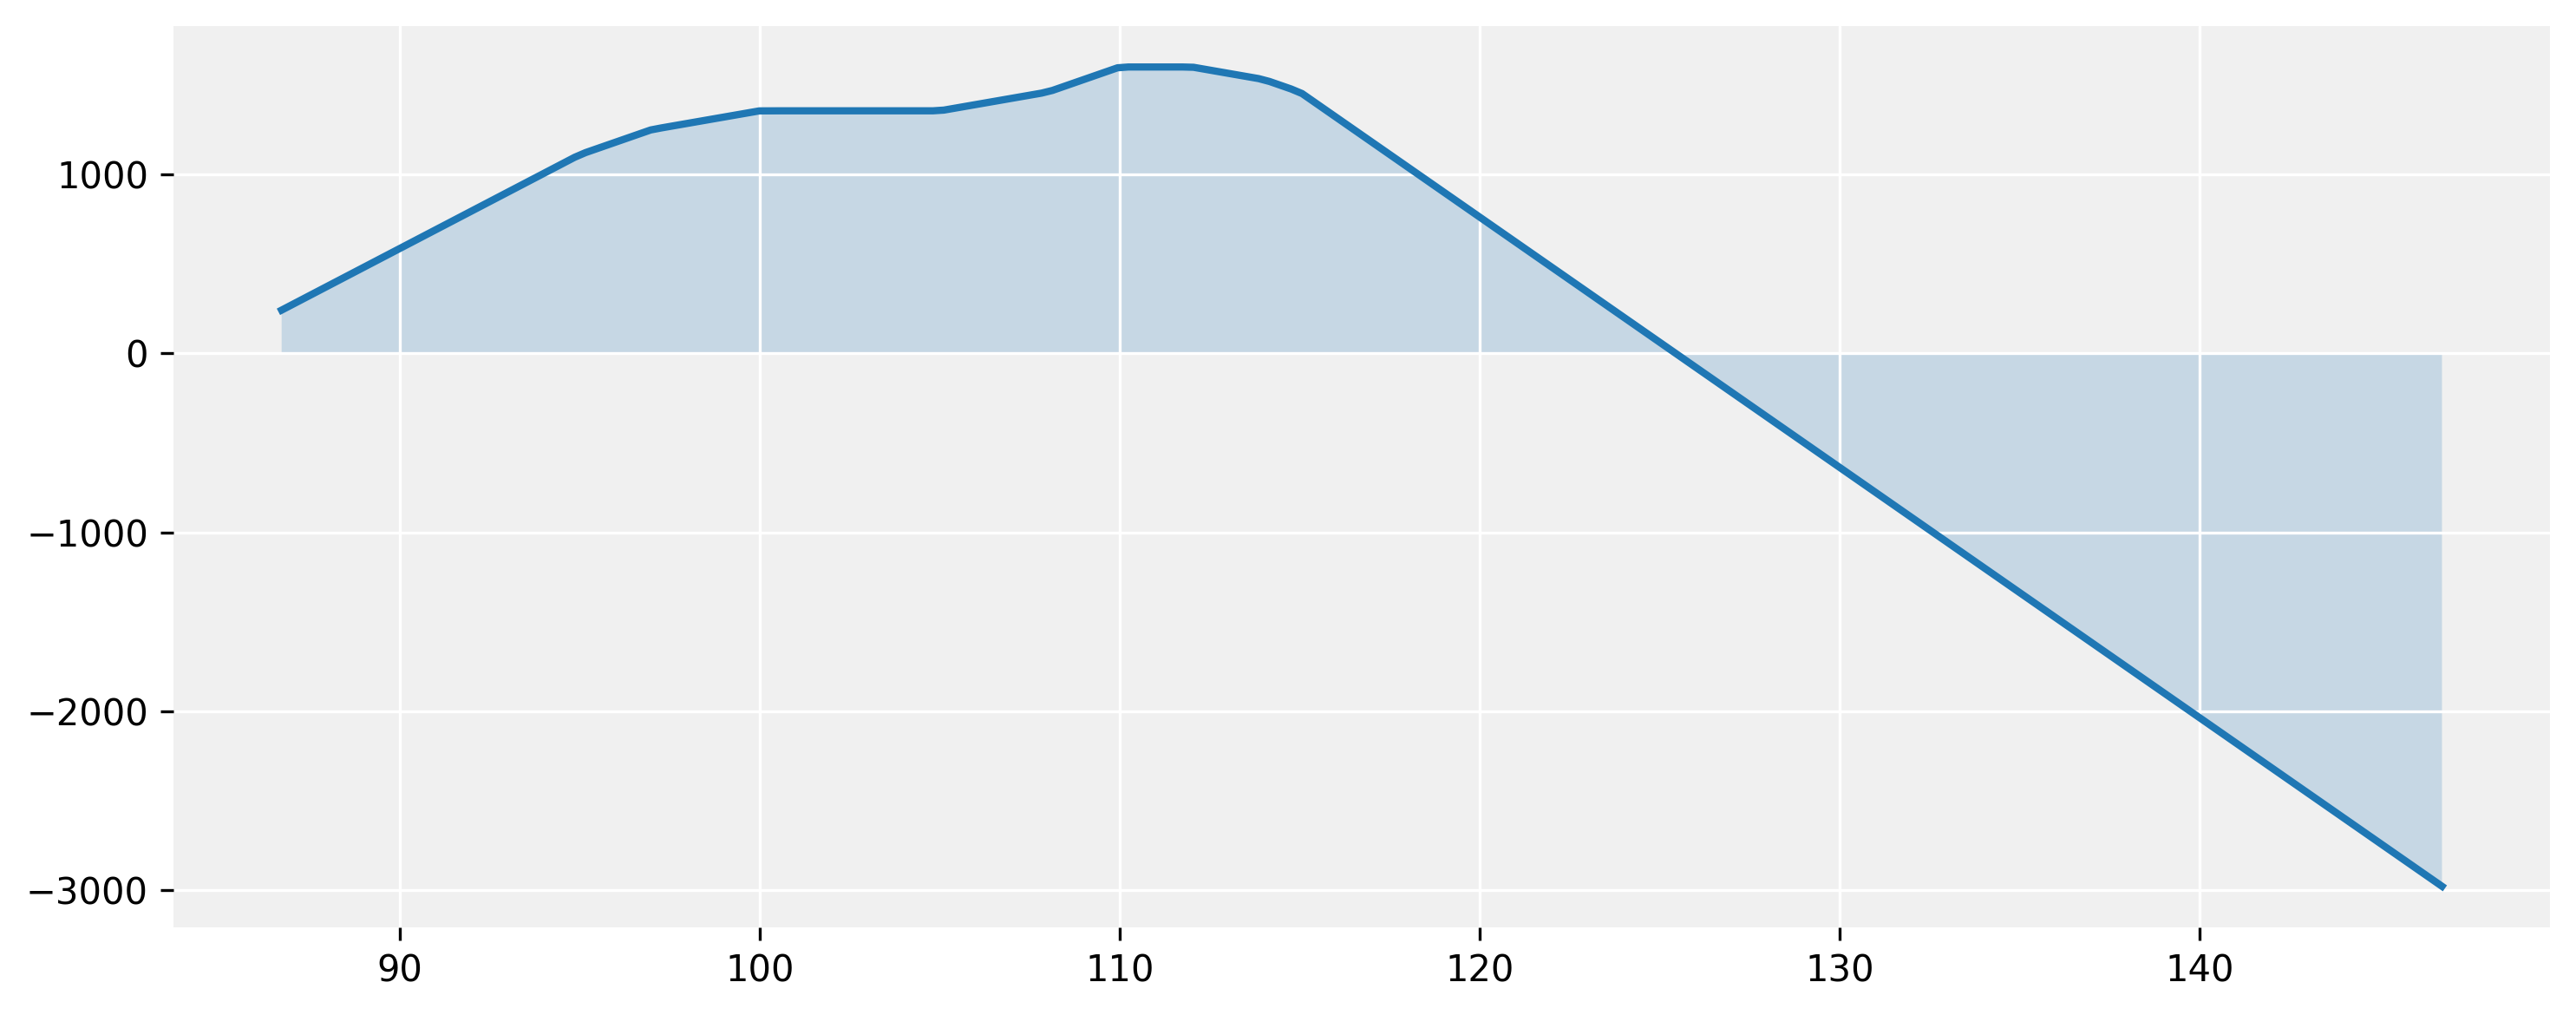

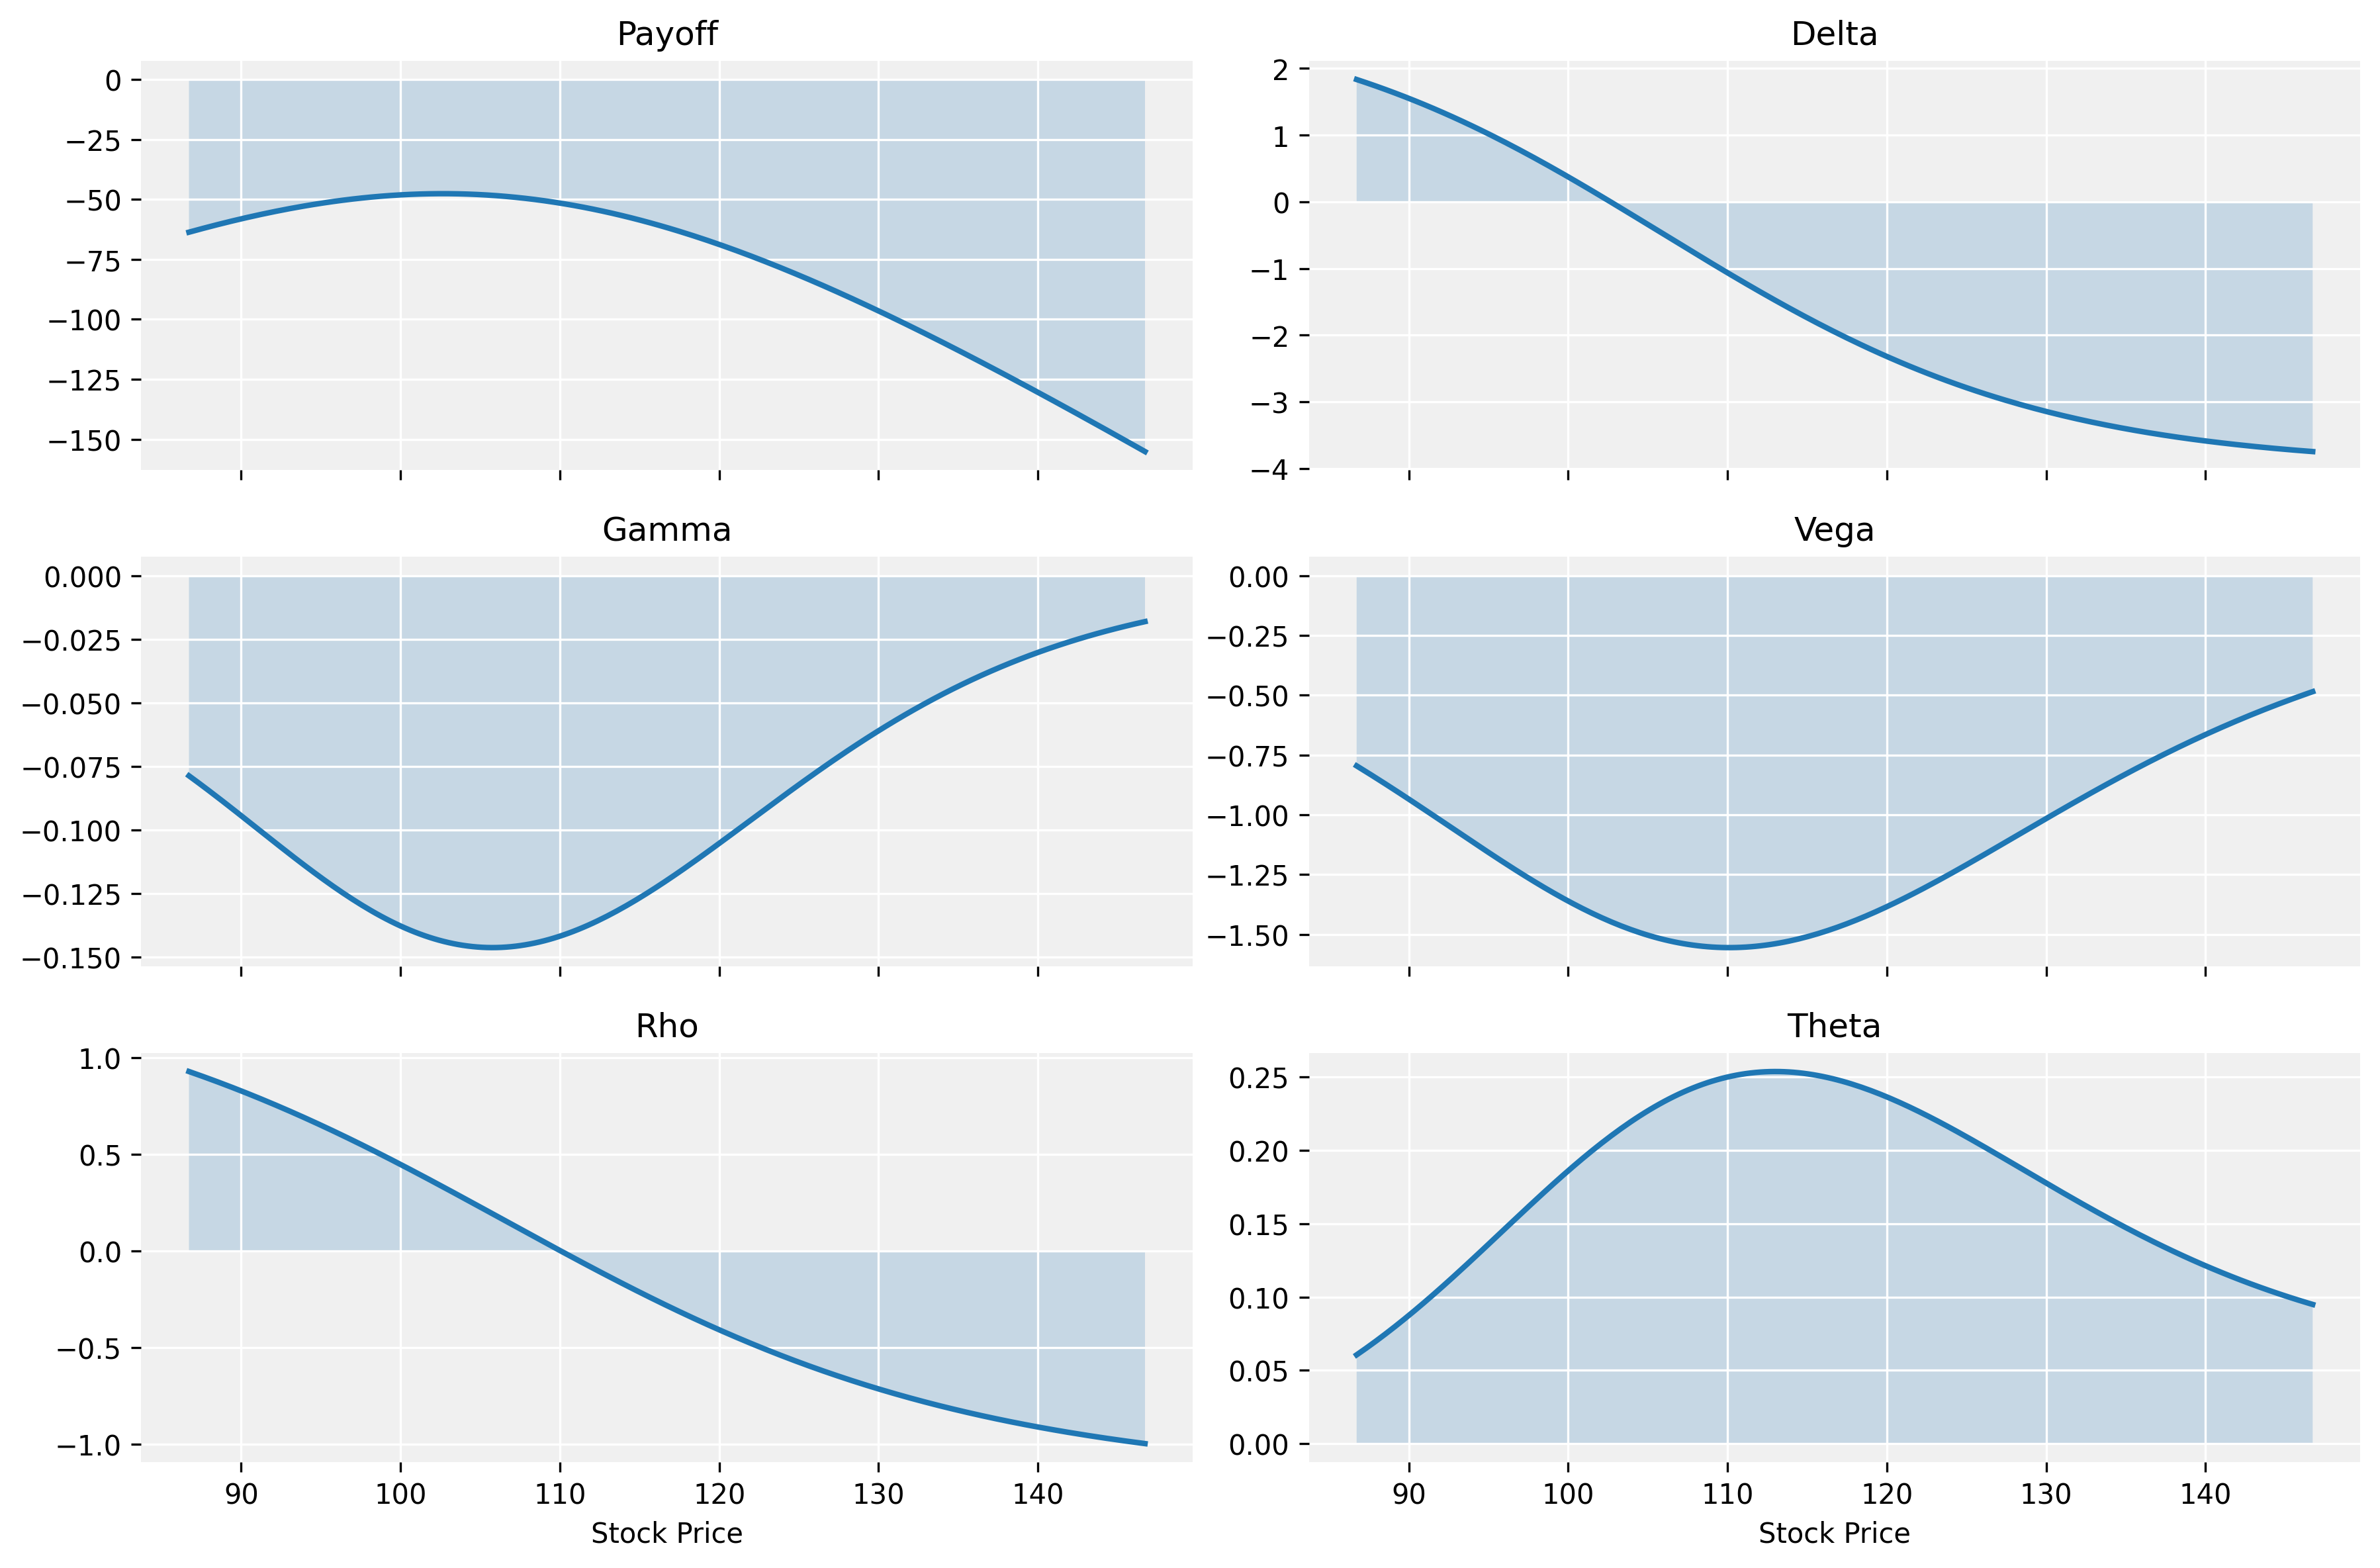

In [24]:
option_portfolio.plot_payoff(S_range)
option_portfolio.plot_greeks(S_range)

# 9. Stock Portfolio Constructor

We hedge our Option portfolio Delta by taking position directly on the underlying, which is constructed exactly with the number of units opposite to the Option portfolio aggregated Delta.

In [25]:
class StockPortfolio:
    def __init__(self, S, units):
        self.S = S
        self.units = units
        self.value = self.S * self.units
        self.table = self.__table()

    def shock_spot(self, pct):
        name = f"Spot {'+' if pct >= 0 else ''}{pct:.2f}%"

        try:
            self.table = self.table.drop(name, axis=1)
        except:
            None

        current_spot = self.S
        new_spot = current_spot * (1 + pct / 100)
        pnl = (new_spot - current_spot) * self.units
        self.table = pd.concat([self.table, pd.DataFrame([pnl], columns=[name])], axis=1)
        return pnl

    def __table(self):
        return pd.DataFrame([self.units], columns=["Delta"])

    def revalue(self, S_pct):
        return (self.S * (1 + S_pct / 100)) * self.units

stock = StockPortfolio(S, -option_portfolio.delta())

# 10. Portfolio Shocks

## 10.1 Portfolio Split between short and long

In [26]:
long_portfolio = OptionPortfolio([i for i in option_portfolio.options if i.side == "long"])
short_portfolio = OptionPortfolio([i for i in option_portfolio.options if i.side == "short"])

print("LONG OPTIONS")
long_portfolio.describe()

print("\nSHORT OPTIONS")
short_portfolio.describe()

LONG OPTIONS
PORTFOLIO COMPOSITION
1. Long Call, Strike: 103, Maturity: 7 months, ITM
2. Long Call, Strike: 112, Maturity: 7 months, ITM
3. Long Call, Strike: 108, Maturity: 7 months, ITM
4. Long Call, Strike: 108, Maturity: 7 months, ITM
5. Long Put, Strike: 105, Maturity: 2 months, OTM

SHORT OPTIONS
PORTFOLIO COMPOSITION
1. Short Put, Strike: 112, Maturity: 2 months, ITM
2. Short Call, Strike: 112, Maturity: 2 months, OTM
3. Short Put, Strike: 103, Maturity: 2 months, ITM
4. Short Call, Strike: 108, Maturity: 2 months, OTM
5. Short Call, Strike: 97, Maturity: 7 months, OTM
6. Short Call, Strike: 114, Maturity: 7 months, OTM
7. Short Call, Strike: 100, Maturity: 7 months, OTM
8. Short Call, Strike: 115, Maturity: 7 months, OTM
9. Short Call, Strike: 115, Maturity: 2 months, OTM
10. Short Call, Strike: 110, Maturity: 7 months, OTM
11. Short Put, Strike: 110, Maturity: 7 months, ITM
12. Short Put, Strike: 95, Maturity: 7 months, ITM


## 10.2 Apply required shocks

In [27]:
# Full Options Portfolio
option_portfolio.shock_spot(1)
option_portfolio.shock_spot(-1)
option_portfolio.shock_spot(10)
option_portfolio.shock_spot(-10)
option_portfolio.shock_spot(20)
option_portfolio.shock_spot(-20)
option_portfolio.shock_sigma(1)
option_portfolio.shock_sigma(-1)
option_portfolio.shock_sigma(20)
option_portfolio.shock_sigma(-20)

# Long Options Portfolio
long_portfolio.shock_spot(1)
long_portfolio.shock_spot(-1)
long_portfolio.shock_spot(10)
long_portfolio.shock_spot(-10)
long_portfolio.shock_spot(20)
long_portfolio.shock_spot(-20)
long_portfolio.shock_sigma(1)
long_portfolio.shock_sigma(-1)
long_portfolio.shock_sigma(20)
long_portfolio.shock_sigma(-20)

# Short Options Portfolio
short_portfolio.shock_spot(1)
short_portfolio.shock_spot(-1)
short_portfolio.shock_spot(10)
short_portfolio.shock_spot(-10)
short_portfolio.shock_spot(20)
short_portfolio.shock_spot(-20)
short_portfolio.shock_sigma(1)
short_portfolio.shock_sigma(-1)
short_portfolio.shock_sigma(20)
short_portfolio.shock_sigma(-20)

# Stock Portfolio
stock.shock_spot(1)
stock.shock_spot(-1)
stock.shock_spot(10)
stock.shock_spot(-10)
stock.shock_spot(20)
stock.shock_spot(-20)

# Summary
option_shocks = option_portfolio.portfolio_totals()[[i for i in option_portfolio.portfolio_totals().columns if "%" in i]]
stock_shocks = stock.table[[i for i in stock.table.columns if "%" in i]]
long_shocks = long_portfolio.portfolio_totals()[[i for i in long_portfolio.portfolio_totals().columns if "%" in i]]
short_shocks = short_portfolio.portfolio_totals()[[i for i in short_portfolio.portfolio_totals().columns if "%" in i]]

## 10.3 Option Portfolio Shocks

In [28]:
option_shocks.iloc[0].to_frame("P&L")

,P&L
Spot +1.00%,-82.584768
Spot -1.00%,76.874944
Spot +10.00%,-1041.678197
Spot -10.00%,480.782373
Spot +20.00%,-2411.868313
Spot -20.00%,291.610829
Vol +1.00%,-51.818033
Vol -1.00%,51.350232
Vol +20.00%,-1092.857499
Vol -20.00%,871.195537


## 10.4 Stock Portfolio Shocks

In [29]:
stock_shocks.iloc[0].to_frame("P&L")

,P&L
Spot +1.00%,79.768693
Spot -1.00%,-79.768693
Spot +10.00%,797.686931
Spot -10.00%,-797.686931
Spot +20.00%,1595.373862
Spot -20.00%,-1595.373862


## 10.5 Long Options Portfolio Shocks

In [30]:
long_shocks.iloc[0].to_frame("P&L")

,P&L
Spot +1.00%,108.733158
Spot -1.00%,-105.629387
Spot +10.00%,1205.986068
Spot -10.00%,-895.972499
Spot +20.00%,2605.134326
Spot -20.00%,-1379.411150
Vol +1.00%,47.908707
Vol -1.00%,-47.593660
Vol +20.00%,993.003603
Vol -20.00%,-815.526183


## 10.6 Short Options Portfolio Shocks

In [31]:
short_shocks.iloc[0].to_frame("P&L")

,P&L
Spot +1.00%,-191.317926
Spot -1.00%,182.504331
Spot +10.00%,-2247.664265
Spot -10.00%,1376.754872
Spot +20.00%,-5017.002640
Spot -20.00%,1671.021980
Vol +1.00%,-99.726739
Vol -1.00%,98.943891
Vol +20.00%,-2085.861102
Vol -20.00%,1686.721720


## 10.6 Full Portfolio Shocks

In [32]:
pd.concat([option_shocks, stock_shocks]).fillna(0).sum().to_frame("P&L")

,P&L
Spot +1.00%,-2.816075
Spot -1.00%,-2.893749
Spot +10.00%,-243.991266
Spot -10.00%,-316.904558
Spot +20.00%,-816.494451
Spot -20.00%,-1303.763033
Vol +1.00%,-51.818033
Vol -1.00%,51.350232
Vol +20.00%,-1092.857499
Vol -20.00%,871.195537


# 11. Historical VaR

## Shock Construction

In [33]:
vix = pd.read_excel("data/VIX.xlsx", index_col=0)
shocks = spot_data[[f"DIS US Equity"]].join(vix)
shocks.columns = ["Underlying", "VIX"]
shocks.Underlying = shocks.Underlying / shocks.Underlying.shift(1) - 1
shocks.VIX = shocks.VIX / shocks.VIX.shift(1) - 1
shocks = shocks.dropna()
shocks["StockPNL"] = shocks.Underlying.apply(lambda x: stock.value - stock.revalue(x * 100))
shocks["OptionsPNL"] = shocks.apply(lambda x: option_portfolio.price() - option_portfolio.revalue(S=x.Underlying * 100, sigma=x.VIX * 100), axis=1)
shocks["PNL"] = shocks.StockPNL + shocks.OptionsPNL
shocks

,Underlying,VIX,StockPNL,OptionsPNL,PNL
2018-01-03,0.003935,-0.063460,-31.392357,-70.347764,-101.740121
2018-01-04,-0.000223,0.007650,1.776665,10.791762,12.568427
2018-01-05,-0.005659,0.000000,45.137337,-44.216076,0.921261
2018-01-08,-0.014160,0.032538,112.949353,-52.261146,60.688207
2018-01-09,-0.000364,0.058824,2.900548,94.467197,97.367745
...,...,...,...,...,...
2026-01-29,0.017607,0.032416,-140.449371,200.598516,60.149145
2026-01-30,0.011744,0.033175,-93.681463,150.977233,57.295770
2026-02-02,-0.073457,-0.063073,585.957615,-526.738325,59.219290
2026-02-03,-0.003156,0.101591,25.174455,144.988627,170.163082


## 1d VaR

In [34]:
VaR_1d = -np.percentile(shocks["PNL"], 5)
VaR_1d

np.float64(153.83093270446471)

## 1d ES

In [35]:
ES_1d = -np.percentile(shocks["PNL"], 2.5)
ES_1d

np.float64(187.84672499568615)

## 5d Adjustment

In [36]:
VaR_5d = VaR_1d * np.sqrt(5)
ES_5d = ES_1d * np.sqrt(5)

VaR_5d, ES_5d

(np.float64(343.9764225693787), np.float64(420.0380464410631))

## VaR

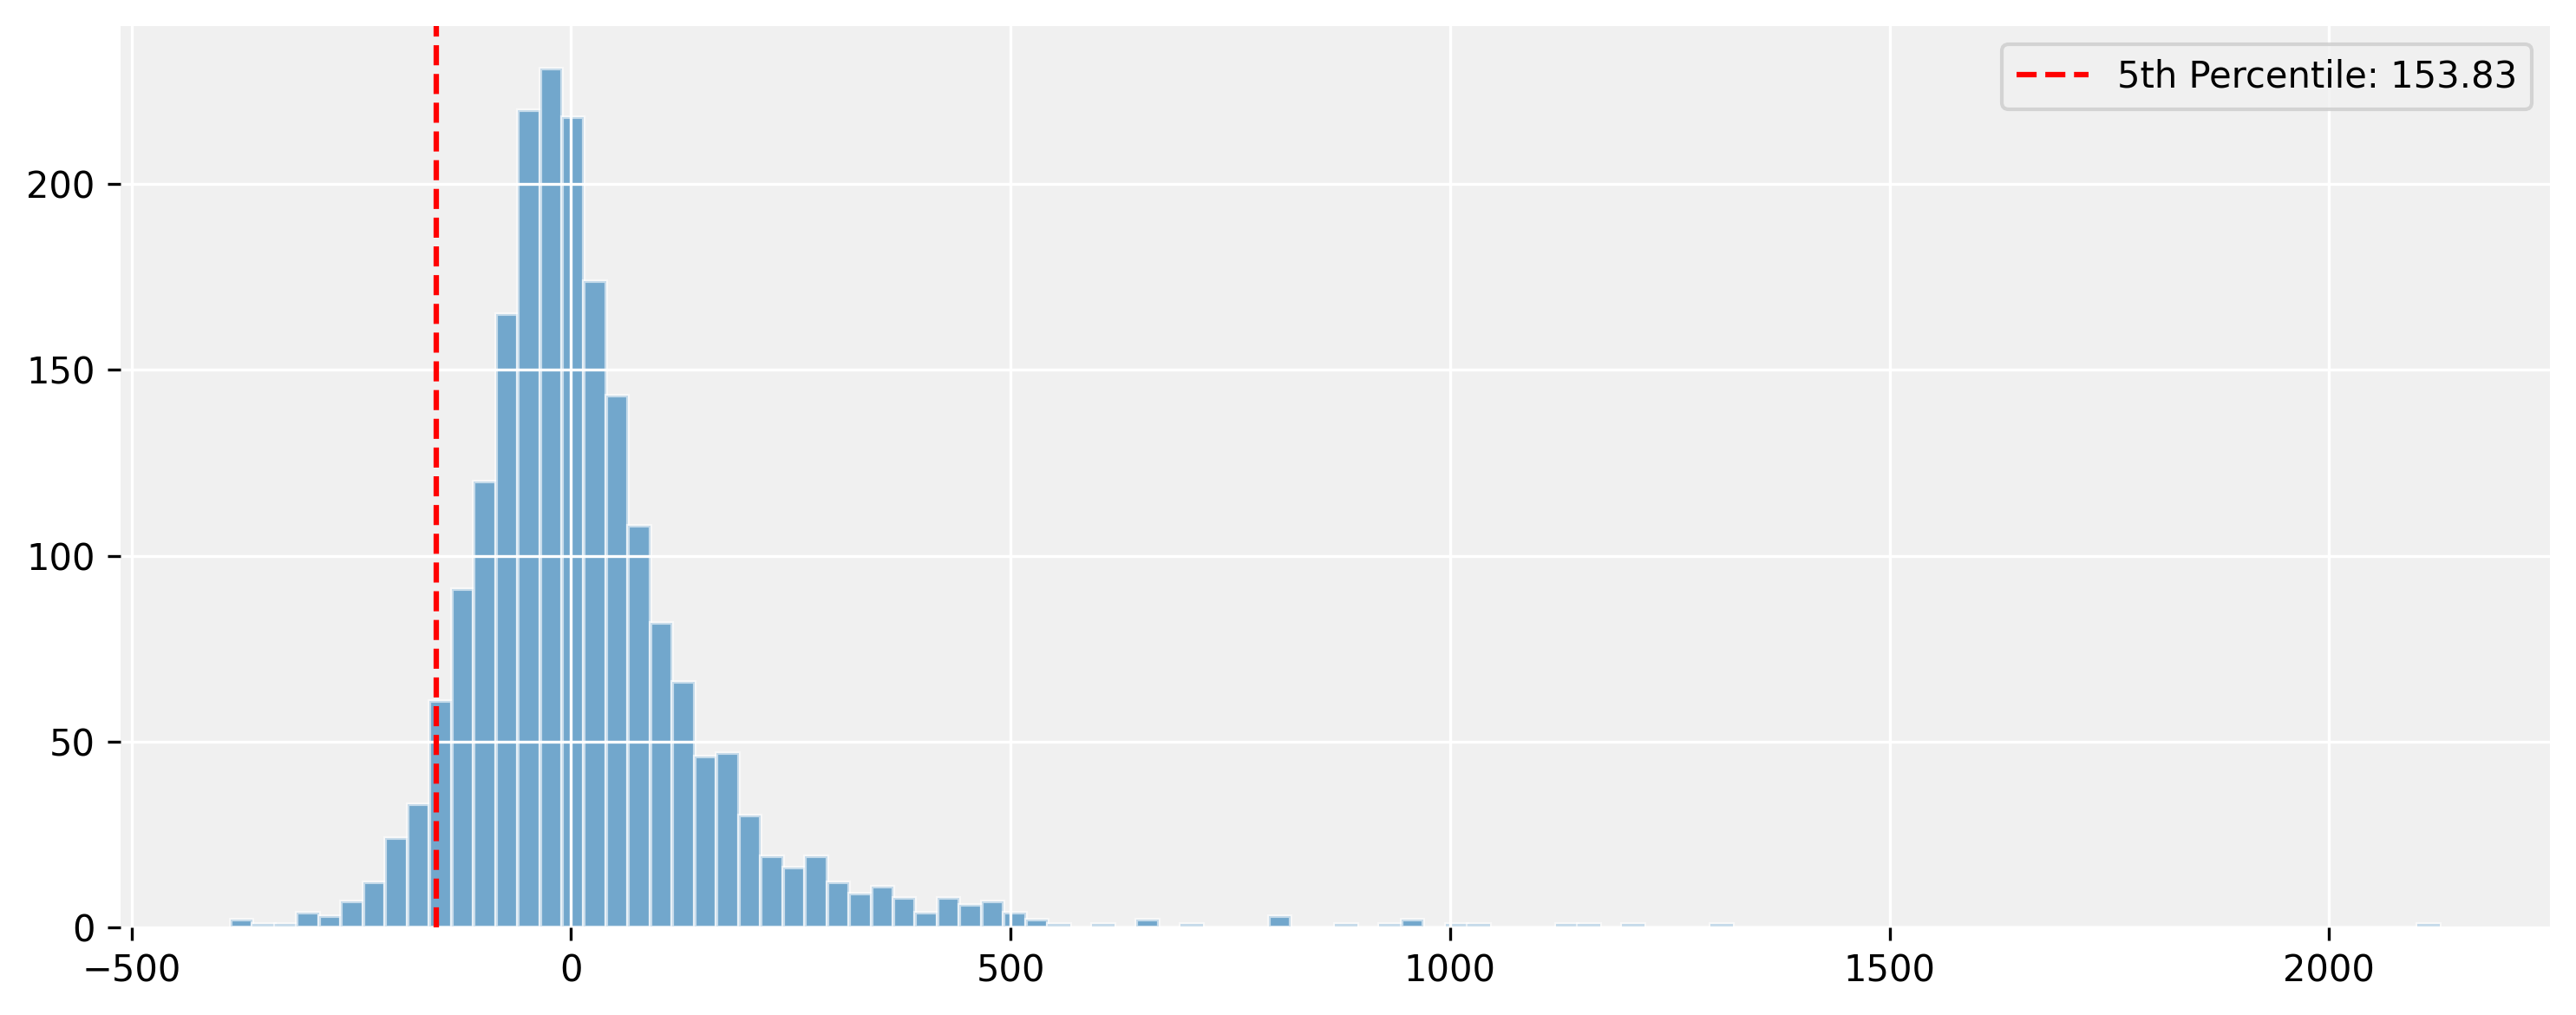

In [37]:
plt.hist(shocks.PNL, bins=100, edgecolor="#FFF", alpha=0.6)
plt.axvline(-VaR_1d, color='red', linestyle='--', linewidth=1.5, label=f'5th Percentile: {VaR_1d:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# 12. Strategy P&L

In [38]:
S_range = np.linspace(S * 0.9, S * 1.1, 50)
vol_range = np.linspace(-0.10, 0.10, 50)

S_grid, vol_grid = np.meshgrid(S_range, vol_range)
PL_grid = np.zeros_like(S_grid)

In [39]:
for i in range(vol_range.shape[0]):
    for j in range(S_range.shape[0]):
        S_shock = (S_grid[i, j] / S - 1) * 100
        vol_multiplier = vol_grid[i, j] * 100

        PL_options = option_portfolio.price() - option_portfolio.revalue(S=S_shock, sigma=vol_multiplier)
        PL_stock = stock.value - stock.revalue(S_shock)

        PL_grid[i, j] = PL_options + PL_stock

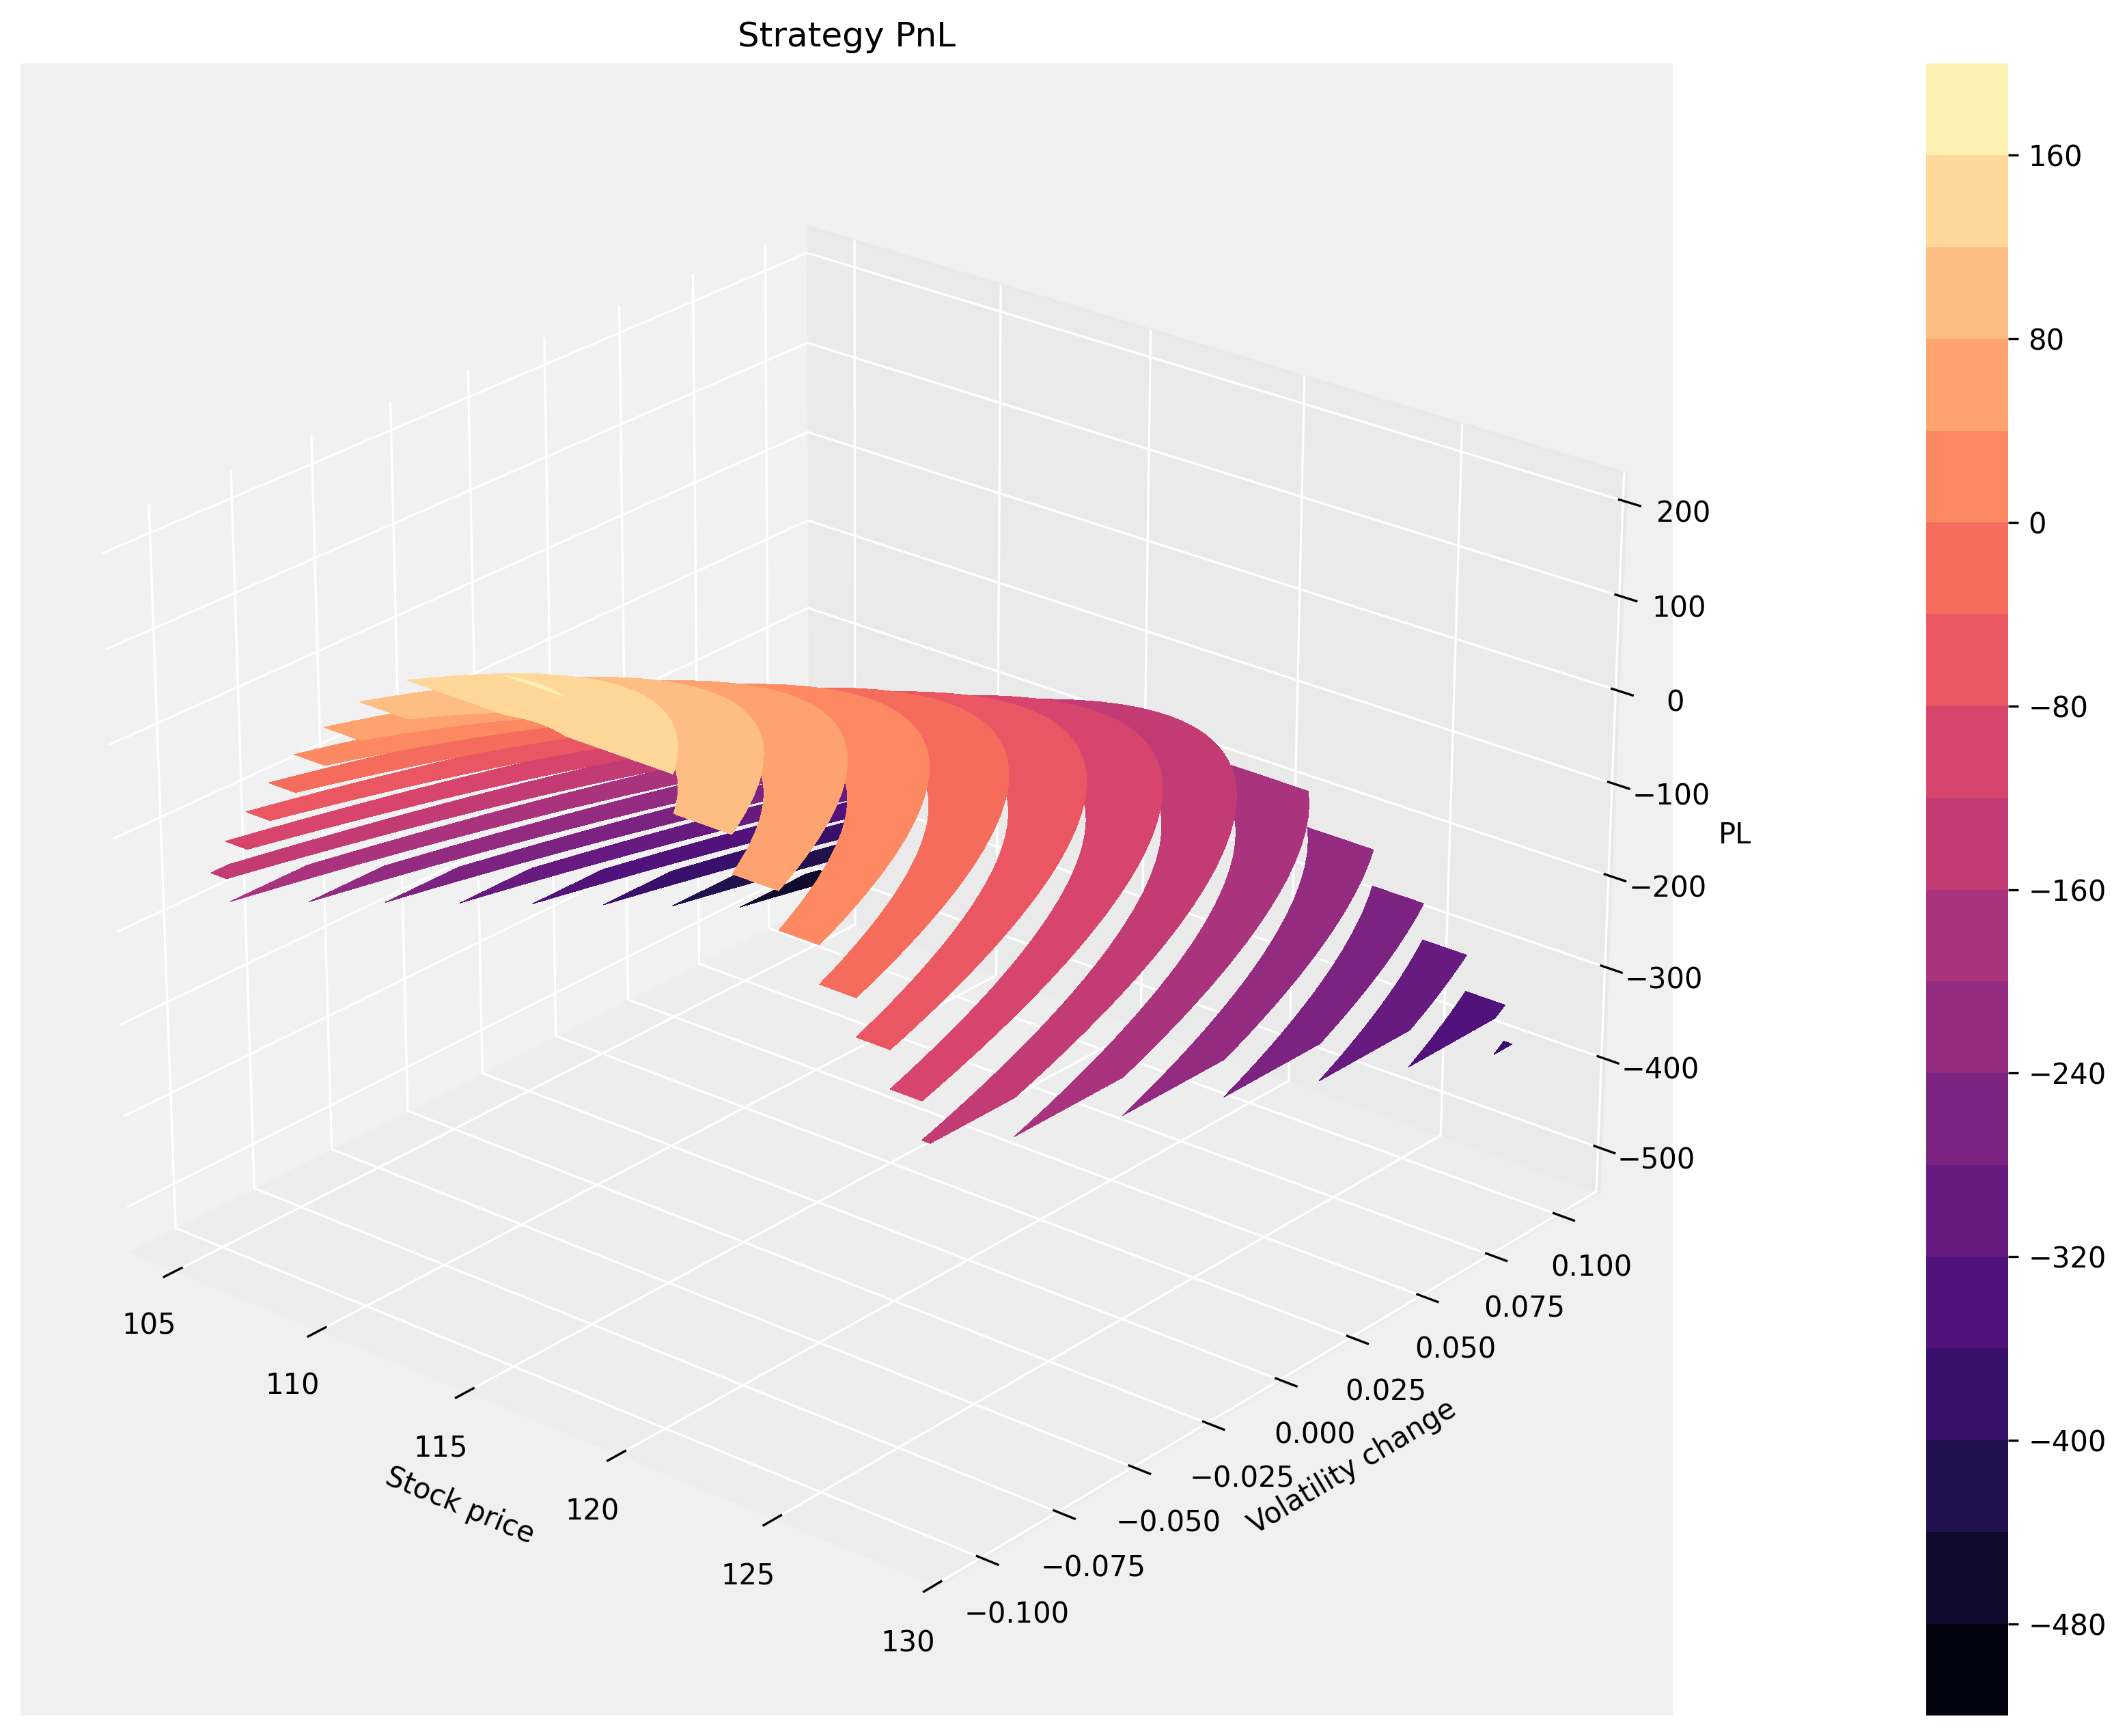

In [40]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(25, 25))
ax = fig.add_subplot(311, projection='3d')

ax.set_xlabel('Stock price')
ax.set_ylabel('Volatility change')
ax.set_zlabel('PL')
ax.scatter(S, 0, 0, color="#C33", s=100)
plt.contourf(S_grid, vol_grid, -PL_grid, levels=20, cmap="magma")
ax.view_init(elev=25, azim=-50)

plt.colorbar()
plt.title("Strategy PnL")
plt.tight_layout()
plt.show()

# 13. Stress Test

In [41]:
# Base values
base_otc = otc_portfolio.price()
base_listed = listed_portfolio.price()
base_stock = stock.value
base_total = base_otc + base_listed + base_stock

# Market data of Spot and VIX
s = spot_data["DIS US Equity"].dropna()
v = vix.iloc[:, 0].dropna()
hist = pd.concat([s.rename("S"), v.rename("VIX")], axis=1).dropna()

spot_ret20 = hist["S"].pct_change(20)
vix_ret20  = hist["VIX"].pct_change(20)

# Repricing under each scenario
def run_scenario(name, typ, S_shock, IV_mult, period=""):
    S_pct = 100 * S_shock
    sigma_pct = 100 * (IV_mult - 1)

    shocked_otc = otc_portfolio.revalue(S=S_pct, sigma=sigma_pct)
    shocked_listed = listed_portfolio.revalue(S=S_pct, sigma=sigma_pct)
    shocked_stock = stock.revalue(S_pct)

    shocked_total = shocked_otc + shocked_listed + shocked_stock

    return {
        "ScenarioType": typ,
        "Scenario": name,
        "Period": period,
        "Spot_shock_%": S_pct,
        "IV_mult": IV_mult,
        "PnL_Total": shocked_total - base_total,
    }

def in_band(df, floor=-2500):
    return df[(df["PnL_Total"] < 1000) & (df["PnL_Total"] >= floor)].copy()

# Historical scenarios

rows = []
common_idx = spot_ret20.dropna().index.intersection(vix_ret20.dropna().index)

for end_date in common_idx:
    S_shock = spot_ret20.loc[end_date]
    IV_mult = 1 + vix_ret20.loc[end_date]

    start_date = hist.index[hist.index.get_loc(end_date) - 20]
    period = f"{start_date.date()} → {end_date.date()}"

    rows.append(run_scenario(f"Hist_{end_date.date()}", "Historical", S_shock, IV_mult, period))

hist_df = pd.DataFrame(rows)
hist_band = in_band(hist_df, floor=-2500).sort_values("PnL_Total")

hist_2 = pd.concat(
    [hist_band.head(1), hist_band.tail(1)],
    ignore_index=True
)

# Hypothetical scenarios

hypo_rows = [
    run_scenario("Spot +25%, Vol x1.30", "Hypothetical", 0.25, 1.30),
    run_scenario("Spot -25%, Vol x1.25", "Hypothetical", -0.25, 1.25),
]

hypo_2 = pd.DataFrame(hypo_rows)

stress_report = pd.concat([hist_2, hypo_2], ignore_index=True)
stress_report = stress_report.sort_values(["ScenarioType", "PnL_Total"]).reset_index(drop=True)

stress_report

,ScenarioType,Scenario,Period,Spot_shock_%,IV_mult,PnL_Total
0,Historical,Hist_2020-04-01,2020-03-04 → 2020-04-01,-20.328172,1.783682,-2430.185747
1,Historical,Hist_2018-03-06,2018-02-05 → 2018-03-06,0.238834,0.491961,726.375383
2,Hypothetical,"Spot -25%, Vol x1.25",,-25.000000,1.250000,-2263.203735
3,Hypothetical,"Spot +25%, Vol x1.30",,25.000000,1.300000,-1387.621325
